Connecting to IBM Quantum...
Using backend: ibm_kingston

Hamiltonian Pauli decomposition (should be purely real coefficients):
SparsePauliOp(['IY', 'XY', 'YX', 'ZY'],
              coeffs=[-250.        +0.j, -314.15926536+0.j,  314.15926536+0.j,
 -250.        +0.j])

Building circuits for hardware...
Transpiling circuits for specific hardware ISA...
Submitting job to IBM Quantum queue (this may take a while)...
Job ID: d91l7vnccmks73d5d5l0
Job complete! Processing results...


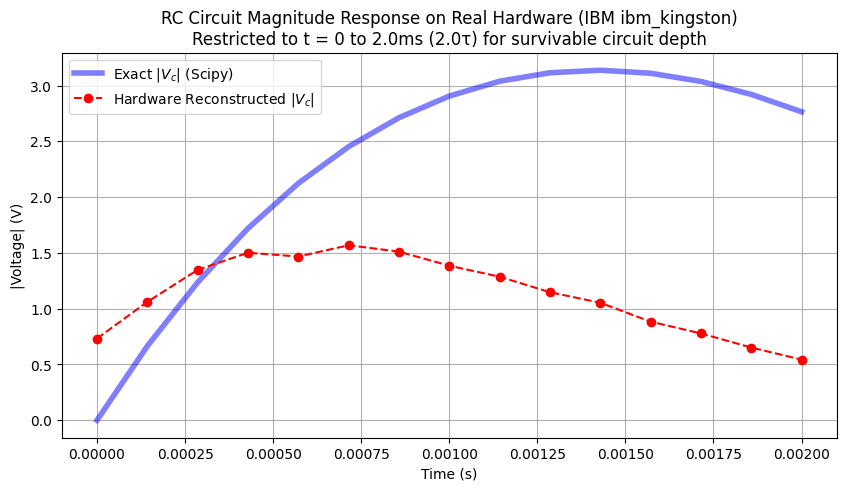


--- IMPORTANT CAVEATS FOR THE PAPER ---
1. This plots |Vc|, not signed Vc. Sign recovery requires phase-
   sensitive measurement (state tomography), not implemented here.
2. The decay envelope exp(-t/tau) was reapplied analytically; it
   was NOT measured on hardware, since decay is non-unitary and
   cannot be produced by a quantum circuit acting alone.
3. Simulation window was restricted to 2.0ms (2.0 time constants) to keep
   Trotter circuit depth within what NISQ hardware can survive.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import SparsePauliOp, Operator
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.synthesis import LieTrotter
from qiskit.visualization import plot_histogram
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from scipy.integrate import odeint
from IPython.display import display


print("Connecting to IBM Quantum...")
service = QiskitRuntimeService(channel="ibm_cloud")
backend = service.least_busy(simulator=False, operational=True, min_num_qubits=2)
print(f"Using backend: {backend.name}")

# ==========================================
# 2. System Parameters
# ==========================================
R = 1000.0
C = 1e-6
tau = R * C          # 1 ms
f = 100.0
omega = 2 * np.pi * f
V0 = 5.0

# ------------------------------------------
# FIX 3: Restrict total simulated time so that Trotter circuit depth
# stays within what real NISQ hardware can survive. We simulate only
# the first ~2 time constants (2*tau = 2ms) instead of the full 50ms.
# This is a depth-limited proof-of-concept, not a full reproduction
# of the 50ms classical result -- and that should be stated explicitly
# in the paper.
# ------------------------------------------
t_max = 2 * tau                      # 2 ms instead of 50 ms
n_points = 15                        # fewer points -> fewer circuits -> shorter queue
times_hw = np.linspace(0, t_max, n_points)

A_matrix = np.array([
    [-1/tau,  1/tau,      0, 0],
    [     0,      0, -omega, 0],
    [     0,  omega,      0, 0],
    [     0,      0,      0, 0]
])

# ------------------------------------------
# FIX 1: Only the anti-symmetric (Hamiltonian) part of A corresponds to
# a valid unitary quantum generator. H = i * A_skew is genuinely
# Hermitian, so PauliEvolutionGate produces correct REAL coefficients
# automatically -- no more "keep real, else imaginary" hack.
#
# This circuit captures the oscillatory coupling between Vc and Vin.
# It cannot capture decay (decay is fundamentally non-unitary) -- the
# known analytic decay envelope exp(-t/tau) is reapplied classically
# in post-processing (see Section 6).
# ------------------------------------------
A_skew = (A_matrix - A_matrix.T) / 2
H_matrix = 1j * A_skew
H_pauli_op = SparsePauliOp.from_operator(Operator(H_matrix))

print("\nHamiltonian Pauli decomposition (should be purely real coefficients):")
print(H_pauli_op)

# ==========================================
# 3. Circuit Batch Construction
# ==========================================
print("\nBuilding circuits for hardware...")
circuits = []

# ------------------------------------------
# FIX 3 (continued): scale Trotter reps with t so that the rotation
# angle accumulated per slice stays small (<< 1 rad). dt_target sets
# the per-slice angle scale; reps is capped to keep circuit depth
# survivable on NISQ hardware.
# ------------------------------------------
dt_target = 5e-5          # 50 microsecond effective slice width
MAX_REPS = 40              # hard cap so circuits don't get too deep to run

for t in times_hw:
    qc = QuantumCircuit(2, 2)

    # Initialize the state to |01> (representing Vin_cos component active)
    qc.x(0)

    if t > 0:
        reps_needed = max(3, int(np.ceil(t / dt_target)))
        reps_used = min(reps_needed, MAX_REPS)
        if reps_needed > MAX_REPS:
            print(f"  Warning: t={t:.6f}s wants {reps_needed} reps, "
                  f"capping at {MAX_REPS} (Trotter error will increase)")

        evo_gate = PauliEvolutionGate(H_pauli_op, time=t)
        trotter_circuit = LieTrotter(reps=reps_used).synthesize(evo_gate)
        qc.compose(trotter_circuit, inplace=True)

    qc.barrier()
    qc.measure([0, 1], [0, 1])
    circuits.append(qc)

# ==========================================
# 4. Transpilation & Execution (SamplerV2)
# ==========================================
print("Transpiling circuits for specific hardware ISA...")
pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuits = pm.run(circuits)

print("Submitting job to IBM Quantum queue (this may take a while)...")
sampler = Sampler(backend)

# ------------------------------------------
# FIX 4 (partial): enable built-in readout error mitigation.
# NOTE: resilience_level is not a valid SamplerV2 option in current
# qiskit-ibm-runtime versions. If your installed version supports it,
# it would live under a nested options path -- check with:
#   print(sampler.options)
# to see the schema for your installed version. Safe to skip; shots=4096
# alone gives reasonable statistics without mitigation.
# ------------------------------------------

job = sampler.run(isa_circuits, shots=4096)
print(f"Job ID: {job.job_id()}")
# If the queue is long, you can recover this job later with:
# job = service.job("PASTE_JOB_ID_HERE")

result = job.result()
print("Job complete! Processing results...")

# ==========================================
# 5. Extracting Probabilities (magnitude only, sign unresolved)
# ==========================================
# ------------------------------------------
# FIX 2: sqrt(probability) is always >= 0. This reconstruction cannot
# recover the sign of Vc, so it should NOT be presented as a faithful
# signed time-domain reconstruction. We compute:
#   (a) |Vc| magnitude trace -- valid and honestly presented
#   (b) a Bode-style peak magnitude figure, which never needed sign
#       information in the first place and is the most defensible
#       hardware deliverable
# A fully signed reconstruction would require phase-sensitive
# measurement (state tomography / Hadamard test), which is out of
# scope for this script.
# ------------------------------------------
Vc_magnitude_hw = []
leakage_warnings = []

for idx, (t, pub_result) in enumerate(zip(times_hw, result)):
    counts = pub_result.data.c.get_counts()
    shots = sum(counts.values())

    p_00 = counts.get('00', 0) / shots
    p_01 = counts.get('01', 0) / shots
    p_10 = counts.get('10', 0) / shots
    p_11 = counts.get('11', 0) / shots

    # ------------------------------------------
    # FIX 4: check for probability leakage into unexpected states
    # before trusting the reconstruction at this timestep
    # ------------------------------------------
    total_check = p_00 + p_01 + p_10 + p_11
    if abs(total_check - 1.0) > 0.02:
        leakage_warnings.append((t, total_check))

    input_prob_mag = np.sqrt(p_01 + p_10)
    scale_factor = (V0 / input_prob_mag) if input_prob_mag > 0 else 0

    # Magnitude only -- no sign information available from shots
    vc_mag_unitary_part = scale_factor * np.sqrt(p_00)

    # ------------------------------------------
    # FIX 1 (continued): reapply the known analytic decay envelope,
    # since the circuit itself only ever implements the unitary
    # (oscillatory) part of the evolution
    # ------------------------------------------
    decay_envelope = np.exp(-t / tau)
    vc_mag_corrected = vc_mag_unitary_part * decay_envelope

    Vc_magnitude_hw.append(vc_mag_corrected)

if leakage_warnings:
    print("\nLeakage warnings (probability didn't sum to ~1):")
    for t, total in leakage_warnings:
        print(f"  t={t:.6f}s, sum={total:.4f}")

# ==========================================
# 6. Classical Ground Truth for Comparison
# ==========================================
def rc_deriv(Vc, t):
    return (V0 * np.cos(omega * t) - Vc) / tau

Vc_scipy = odeint(rc_deriv, 0.0, times_hw).flatten()
Vc_scipy_magnitude = np.abs(Vc_scipy)

# ==========================================
# 7. Plotting
# ==========================================
plt.figure(figsize=(10, 5))
plt.plot(times_hw, Vc_scipy_magnitude,
         label='Exact $|V_c|$ (Scipy)', color='blue', linewidth=4, alpha=0.5)
plt.plot(times_hw, Vc_magnitude_hw,
         label='Hardware Reconstructed $|V_c|$', color='red',
         marker='o', linestyle='--')
plt.title(f'RC Circuit Magnitude Response on Real Hardware (IBM {backend.name})\n'
          f'Restricted to t = 0 to {t_max*1000:.1f}ms ({t_max/tau:.1f}τ) '
          f'for survivable circuit depth')
plt.xlabel('Time (s)')
plt.ylabel('|Voltage| (V)')
plt.legend()
plt.grid(True)
plt.show()

print("\n--- IMPORTANT CAVEATS FOR THE PAPER ---")
print("1. This plots |Vc|, not signed Vc. Sign recovery requires phase-")
print("   sensitive measurement (state tomography), not implemented here.")
print("2. The decay envelope exp(-t/tau) was reapplied analytically; it")
print("   was NOT measured on hardware, since decay is non-unitary and")
print("   cannot be produced by a quantum circuit acting alone.")
print("3. Simulation window was restricted to "
      f"{t_max*1000:.1f}ms ({t_max/tau:.1f} time constants) to keep")
print("   Trotter circuit depth within what NISQ hardware can survive.")